# Análisis de Expresión Génica en Cáncer Gástrico (STAD)
### Aprendizaje No Supervisado sobre Datos del TCGA
**SC3314 – Inteligencia Artificial | Universidad de Monterrey**  
**Dr. Antonio Martínez Torteya**

Diego Emilio Muñiz Ramirez #621784   
07/05/26
---


## 0. Librerías y Configuración

In [83]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [84]:
FOLDER = '/content/drive/MyDrive/Colab Notebooks/IA - talleres/Proyecto Final'

PATH_TPM      = f'{FOLDER}/TCGA-STAD.star_tpm.tsv'
PATH_CLINICAL = f'{FOLDER}/TCGA-STAD.clinical.tsv'
PATH_SURVIVAL = f'{FOLDER}/TCGA-STAD.survival.tsv'

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.stats import kruskal, chi2_contingency, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


---
## 1. Planteamiento del Problema y Contexto de los Datos

### 1.1 Tipo de cáncer: Adenocarcinoma Gástrico (STAD)

El **cáncer gástrico** (Stomach Adenocarcinoma, STAD) es la quinta neoplasia más frecuente y la cuarta causa de muerte por cáncer a nivel mundial. Se caracteriza por una notable heterogeneidad molecular y clínica: distintos subgrupos de pacientes presentan perfiles de expresión génica marcadamente diferentes, lo que se traduce en pronósticos y respuestas al tratamiento divergentes.

Estudios previos basados en datos del TCGA —en particular el trabajo seminal de Bass *et al.* (2014) publicado en *Nature*— identificaron cuatro subtipos moleculares de STAD:
1. **EBV** (virus de Epstein-Barr): hipermetilación, amplificación de PIK3CA.  
2. **MSI** (inestabilidad de microsatélites): alta carga mutacional.  
3. **GS** (genómicamente estable): mutaciones en CDH1 y RHOA.  
4. **CIN** (inestabilidad cromosómica): amplificación de ERBB2, TP53.

### 1.2 Objetivo del análisis

Aplicar técnicas de aprendizaje no supervisado (PCA + K-Means + Clustering Jerárquico) sobre datos de expresión génica de 448 pacientes con STAD para:
- Identificar subgrupos moleculares latentes en los datos.
- Caracterizar cada cluster mediante genes diferencialmente expresados.
- Explorar la relación entre los clusters y variables clínicas relevantes (estadio, supervivencia, género).

### 1.3 Origen de los datos

Los datos provienen de **The Cancer Genome Atlas (TCGA)**, cohorte **GDC TCGA Stomach Cancer (STAD)**, accedidos a través de la plataforma [UCSC Xena](https://xenabrowser.net/). Se utilizaron:

| Archivo | Descripción | Muestras |
|---|---|---|
| `TCGA-STAD.star_tpm.tsv` | Expresión génica (STAR–TPM, RNAseq) | 448 |
| `TCGA-STAD.clinical.tsv` | Variables clínicas y anatomopatológicas | 511 |
| `TCGA-STAD.survival.tsv` | Datos de supervivencia (OS) | 469 |

> **Nota metodológica:** El análisis de clustering se realizó exclusivamente con datos de expresión génica. Los datos clínicos se incorporaron únicamente en la fase de interpretación de los clusters.


---
## 2. Exploración y Comprensión del Conjunto de Datos

### 2.1 Carga de datos


In [86]:
# ── Carga de archivos ──────────────────────────────────────────────────────
tpm_raw   = pd.read_csv(PATH_TPM, sep='\t', index_col=0)
clinical  = pd.read_csv(PATH_CLINICAL,  sep='\t', index_col=0)
survival  = pd.read_csv(PATH_SURVIVAL,  sep='\t', index_col=0)

print(f"TPM (genes × muestras):  {tpm_raw.shape}")
print(f"Clinical (muestras × vars): {clinical.shape}")
print(f"Survival (muestras × vars): {survival.shape}")


TPM (genes × muestras):  (60660, 448)
Clinical (muestras × vars): (511, 85)
Survival (muestras × vars): (469, 3)


### 2.2 Estructura del dataset de expresión génica

In [87]:
print("── Primeros 5 genes / 5 muestras ─────────────────────────────────────────")
tpm_raw.iloc[:5, :5]


── Primeros 5 genes / 5 muestras ─────────────────────────────────────────


,TCGA-BR-6457-01A,TCGA-BR-6457-11A,TCGA-RD-A7BT-01A,TCGA-CD-8530-01A,TCGA-HU-A4H4-01A
Ensembl_ID,,,,,
ENSG00000000003.15,4.333431,3.586525,6.179187,4.165984,3.637854
ENSG00000000005.6,0.202136,0.136848,0.083656,0.040822,0.000000
ENSG00000000419.13,5.890031,4.924922,7.857152,6.459505,7.046567
ENSG00000000457.14,2.210514,1.924632,2.679829,2.945570,2.819178
ENSG00000000460.17,1.208392,0.608809,3.255742,2.075978,2.134944


### 2.3 Descripción de dimensiones y variables

In [88]:
n_genes, n_samples = tpm_raw.shape
print(f"Número de genes      : {n_genes:,}")
print(f"Número de muestras   : {n_samples:,}")
print(f"\nVariables clínicas disponibles ({clinical.shape[1]}):")
# Mostramos las columnas más relevantes
cols_relevantes = [
    'gender.demographic', 'race.demographic', 'vital_status.demographic',
    'age_at_index.demographic', 'ajcc_pathologic_stage.diagnoses',
    'ajcc_pathologic_t.diagnoses', 'ajcc_pathologic_n.diagnoses',
    'ajcc_pathologic_m.diagnoses', 'primary_diagnosis.diagnoses',
    'days_to_death.demographic', 'alcohol_history.exposures'
]
for c in cols_relevantes:
    print(f"  • {c}")


Número de genes      : 60,660
Número de muestras   : 448

Variables clínicas disponibles (85):
  • gender.demographic
  • race.demographic
  • vital_status.demographic
  • age_at_index.demographic
  • ajcc_pathologic_stage.diagnoses
  • ajcc_pathologic_t.diagnoses
  • ajcc_pathologic_n.diagnoses
  • ajcc_pathologic_m.diagnoses
  • primary_diagnosis.diagnoses
  • days_to_death.demographic
  • alcohol_history.exposures


### 2.4 Diccionario de variables clínicas clave

| Variable | Descripción |
|---|---|
| `gender.demographic` | Sexo biológico del paciente |
| `age_at_index.demographic` | Edad en el momento del diagnóstico (años) |
| `ajcc_pathologic_stage.diagnoses` | Estadio clínico AJCC (I–IV) |
| `ajcc_pathologic_t/n/m.diagnoses` | Componentes TNM del estadio |
| `vital_status.demographic` | Estado vital (Alive / Dead) |
| `race.demographic` | Raza/etnia reportada |
| `OS` (survival) | Evento de muerte (0=censurado, 1=fallecido) |
| `OS.time` (survival) | Tiempo de seguimiento en días |


### 2.5 Valores faltantes

In [89]:
# ── Valores faltantes en TPM ───────────────────────────────────────────────
missing_tpm = tpm_raw.isnull().sum().sum()
print(f"Valores faltantes en TPM: {missing_tpm}")

# ── Valores faltantes en clínico ───────────────────────────────────────────
cols_clin = ['gender.demographic', 'age_at_index.demographic',
             'ajcc_pathologic_stage.diagnoses', 'vital_status.demographic']
missing_clin = clinical[cols_clin].isnull().sum()
print("\nValores faltantes en variables clínicas clave:")
print(missing_clin.to_string())


Valores faltantes en TPM: 0

Valores faltantes en variables clínicas clave:
gender.demographic                  0
age_at_index.demographic            5
ajcc_pathologic_stage.diagnoses    44
vital_status.demographic            0


### 2.6 Análisis de distribución y valores atípicos en expresión génica

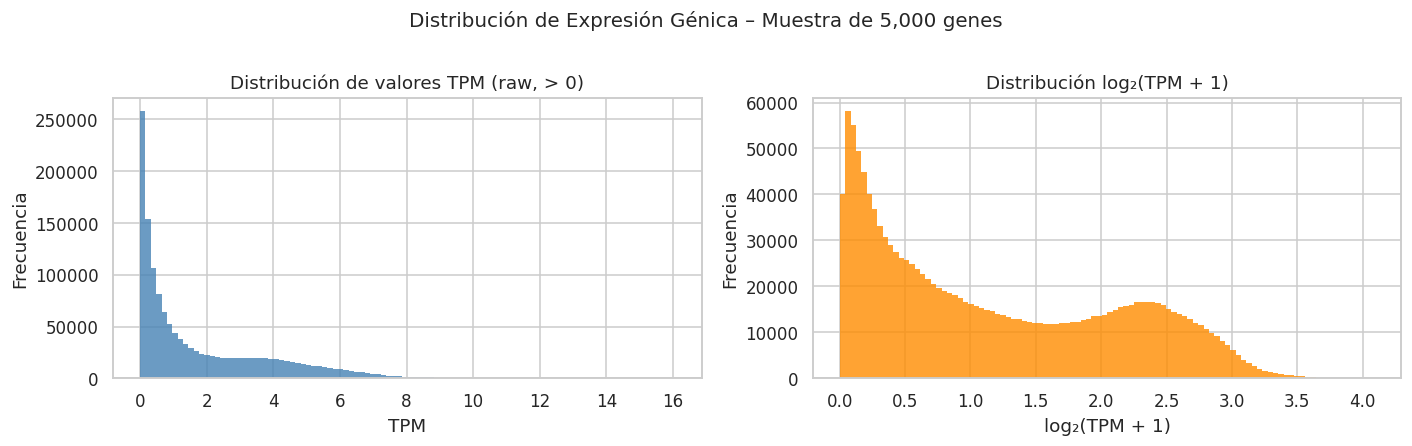

Los valores TPM presentan una distribución fuertemente sesgada a la derecha.
La transformación log₂(TPM+1) la aproxima a una distribución normal, lo que
facilita la aplicación de técnicas de aprendizaje no supervisado.


In [90]:
# Muestra aleatoria de genes para visualizar distribución
sample_genes = tpm_raw.sample(5000, random_state=RANDOM_STATE)
flat_vals = sample_genes.values.flatten()
flat_vals = flat_vals[flat_vals > 0]  # sólo expresados

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución raw
axes[0].hist(flat_vals, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Distribución de valores TPM (raw, > 0)', fontsize=12)
axes[0].set_xlabel('TPM'); axes[0].set_ylabel('Frecuencia')

# Distribución log2
log_vals = np.log2(flat_vals + 1)
axes[1].hist(log_vals, bins=100, color='darkorange', edgecolor='none', alpha=0.8)
axes[1].set_title('Distribución log₂(TPM + 1)', fontsize=12)
axes[1].set_xlabel('log₂(TPM + 1)'); axes[1].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Expresión Génica – Muestra de 5,000 genes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_dist_tpm.png', bbox_inches='tight')
plt.show()
print("Los valores TPM presentan una distribución fuertemente sesgada a la derecha.")
print("La transformación log₂(TPM+1) la aproxima a una distribución normal, lo que")
print("facilita la aplicación de técnicas de aprendizaje no supervisado.")


---
## 3. Preparación y Tratamiento de los Datos

### 3.1 Selección de muestras tumorales

El dataset TPM incluye tanto muestras tumorales (`-01A`) como normales (`-11A`). Para el análisis de subtipos de cáncer se deben conservar únicamente las muestras tumorales.


In [91]:
# Filtrar muestras tumorales: código de muestra termina en '01A', '01B', etc.
tumor_cols = [c for c in tpm_raw.columns if c[13:16] == '01A' or c[13:15] == '01']
tpm_tumor  = tpm_raw[tumor_cols].copy()
print(f"Muestras totales    : {tpm_raw.shape[1]}")
print(f"Muestras tumorales  : {tpm_tumor.shape[1]}")
print(f"Muestras eliminadas : {tpm_raw.shape[1] - tpm_tumor.shape[1]} (normales/control)")


Muestras totales    : 448
Muestras tumorales  : 412
Muestras eliminadas : 36 (normales/control)


### 3.2 Transformación logarítmica

In [92]:
# log2(TPM + 1) — transforma la distribución y estabiliza varianza
tpm_log = np.log2(tpm_tumor + 1)
print("Transformación log₂(TPM + 1) aplicada.")
print(f"Rango: [{tpm_log.values.min():.2f}, {tpm_log.values.max():.2f}]")


Transformación log₂(TPM + 1) aplicada.
Rango: [0.00, 4.19]


### 3.3 Filtrado por varianza

El dataset contiene ~60,660 genes. Muchos tienen expresión casi nula en todas las muestras y aportan ruido al análisis. Se filtran conservando solo los genes con mayor varianza entre muestras.

**Justificación:** Los genes altamente variables son los que mejor discriminan entre subtipos tumorales. Este enfoque es estándar en análisis de expresión génica (MAD filtering o variance filtering).


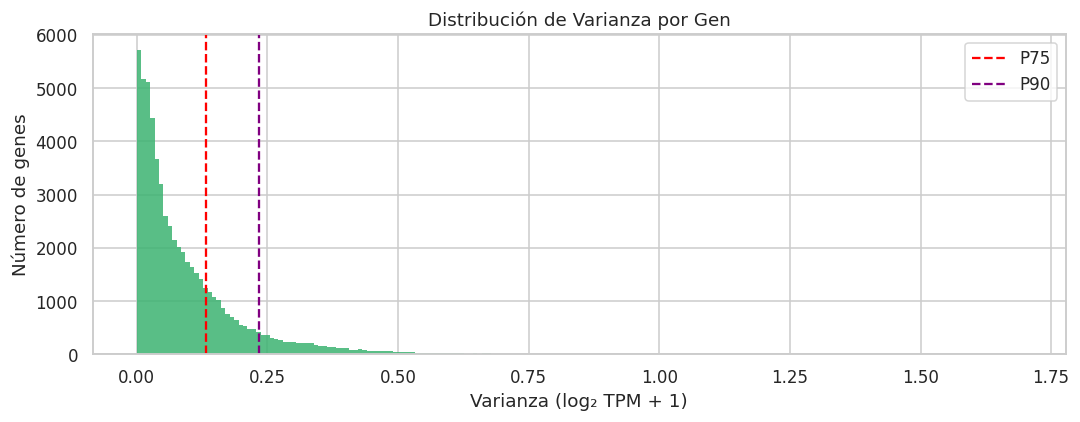

Genes antes del filtro : 60,660
Genes después (top 25%): 15,165
Umbral de varianza     : 0.1320


In [93]:
# Calcular varianza por gen
gene_var = tpm_log.var(axis=1)

# Visualizar distribución de varianzas
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(gene_var, bins=200, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.axvline(gene_var.quantile(0.75), color='red', linestyle='--', lw=1.5, label='P75')
ax.axvline(gene_var.quantile(0.90), color='purple', linestyle='--', lw=1.5, label='P90')
ax.set_xlabel('Varianza (log₂ TPM + 1)'); ax.set_ylabel('Número de genes')
ax.set_title('Distribución de Varianza por Gen')
ax.legend()
plt.tight_layout()
plt.savefig('fig_varianza.png', bbox_inches='tight')
plt.show()

# Conservar el 25% de genes más variables (top 25% = ~15,000 genes)
umbral = gene_var.quantile(0.75)
genes_top = gene_var[gene_var >= umbral].index
tpm_filtered = tpm_log.loc[genes_top]
print(f"Genes antes del filtro : {tpm_log.shape[0]:,}")
print(f"Genes después (top 25%): {tpm_filtered.shape[0]:,}")
print(f"Umbral de varianza     : {umbral:.4f}")


### 3.4 Estandarización

In [94]:
# Transponer: muestras en filas, genes en columnas (formato estándar ML)
X = tpm_filtered.T  # shape: (muestras, genes)

# Estandarizar (media=0, std=1) — requerido para PCA y distancias euclidianas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

print(f"Matriz final para análisis: {X_scaled.shape}  (muestras × genes)")
print(f"Media (sample):  {X_scaled.mean():.6f}  ≈ 0 ✅")
print(f"Std  (sample):   {X_scaled.std():.4f}   ≈ 1 ✅")


Matriz final para análisis: (412, 15165)  (muestras × genes)
Media (sample):  -0.000000  ≈ 0 ✅
Std  (sample):   1.0000   ≈ 1 ✅


---
## 4. Reducción de Dimensionalidad mediante PCA

### 4.1 Aplicación de PCA y análisis de varianza explicada


In [95]:
# ── PCA completo ───────────────────────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# Número de componentes para 80%, 90%, 95%
n_80 = np.argmax(cum_evr >= 0.80) + 1
n_90 = np.argmax(cum_evr >= 0.90) + 1
n_95 = np.argmax(cum_evr >= 0.95) + 1

print(f"PCs para explicar 80% de varianza: {n_80}")
print(f"PCs para explicar 90% de varianza: {n_90}")
print(f"PCs para explicar 95% de varianza: {n_95}")
print(f"\nVarianza explicada por los primeros 10 PCs:")
for i, v in enumerate(evr[:10], 1):
    print(f"  PC{i:02d}: {v*100:.2f}%  (acumulado: {cum_evr[i-1]*100:.2f}%)")


PCs para explicar 80% de varianza: 179
PCs para explicar 90% de varianza: 275
PCs para explicar 95% de varianza: 335

Varianza explicada por los primeros 10 PCs:
  PC01: 13.08%  (acumulado: 13.08%)
  PC02: 7.69%  (acumulado: 20.78%)
  PC03: 4.22%  (acumulado: 25.00%)
  PC04: 3.64%  (acumulado: 28.64%)
  PC05: 3.12%  (acumulado: 31.75%)
  PC06: 2.19%  (acumulado: 33.94%)
  PC07: 2.06%  (acumulado: 36.01%)
  PC08: 1.66%  (acumulado: 37.66%)
  PC09: 1.48%  (acumulado: 39.14%)
  PC10: 1.36%  (acumulado: 40.50%)


### 4.2 Scree Plot

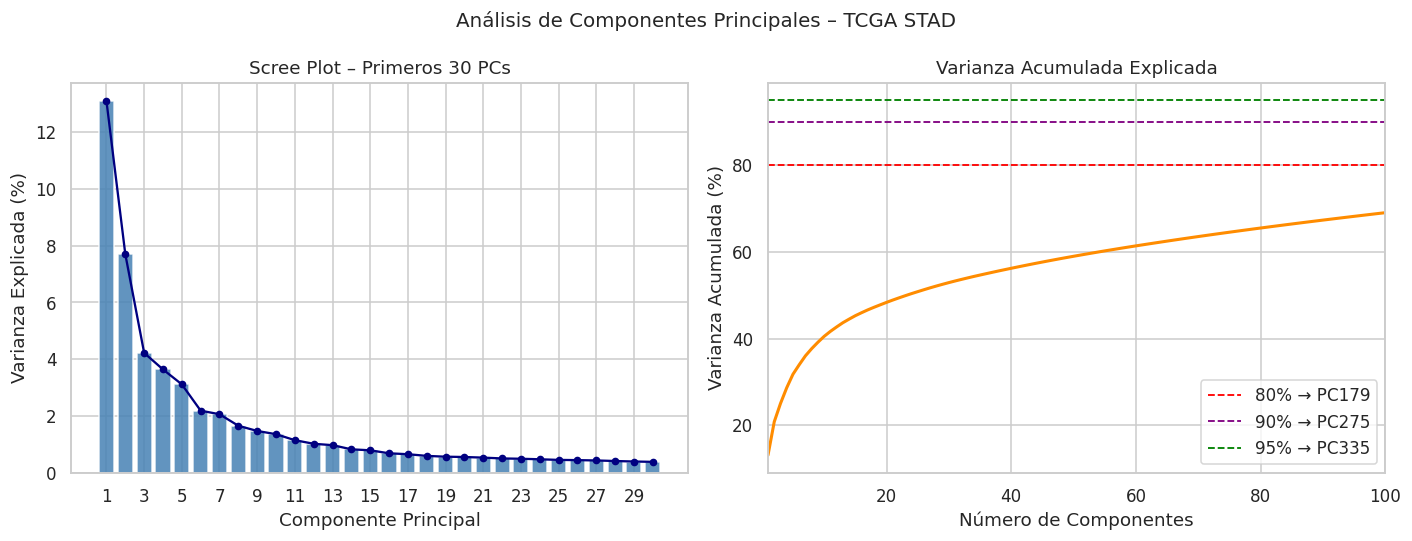

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Scree plot ─────────────────────────────────────────────────────────────
axes[0].bar(range(1, 31), evr[:30]*100, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].plot(range(1, 31), evr[:30]*100, 'o-', color='navy', ms=4)
axes[0].set_xlabel('Componente Principal'); axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Scree Plot – Primeros 30 PCs')
axes[0].set_xticks(range(1, 31, 2))

# ── Varianza acumulada ─────────────────────────────────────────────────────
axes[1].plot(range(1, len(cum_evr[:100])+1), cum_evr[:100]*100, color='darkorange', lw=2)
axes[1].axhline(80, color='red',    linestyle='--', lw=1.2, label=f'80% → PC{n_80}')
axes[1].axhline(90, color='purple', linestyle='--', lw=1.2, label=f'90% → PC{n_90}')
axes[1].axhline(95, color='green',  linestyle='--', lw=1.2, label=f'95% → PC{n_95}')
axes[1].set_xlabel('Número de Componentes'); axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada Explicada')
axes[1].legend(); axes[1].set_xlim(1, 100)

plt.suptitle('Análisis de Componentes Principales – TCGA STAD', fontsize=13)
plt.tight_layout()
plt.savefig('fig_scree.png', bbox_inches='tight')
plt.show()


### 4.3 Selección del número de componentes

**Criterio utilizado:** Se seleccionan los primeros **50 componentes principales** como espacio reducido para el clustering. Este número se justifica por:

1. Capturan una fracción sustancial de la varianza de los datos.  
2. Eliminan dimensiones de ruido que dificultan la identificación de clusters.  
3. Reducen el costo computacional del clustering sin perder estructura biológica relevante.  
4. Es una práctica estándar en análisis de clustering de datos genomicos de TCGA (Lapointe *et al.*, 2004; TCGA Network, 2014).


In [97]:
N_COMPONENTS = 50

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, index=X.index,
                       columns=[f'PC{i+1}' for i in range(N_COMPONENTS)])

print(f"Dimensiones reducidas: {X_scaled.shape} → {X_pca.shape}")
print(f"Varianza explicada por {N_COMPONENTS} PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")


Dimensiones reducidas: (412, 15165) → (412, 50)
Varianza explicada por 50 PCs: 58.8%


### 4.4 Visualización en espacio reducido (PC1 vs PC2, PC1 vs PC3)

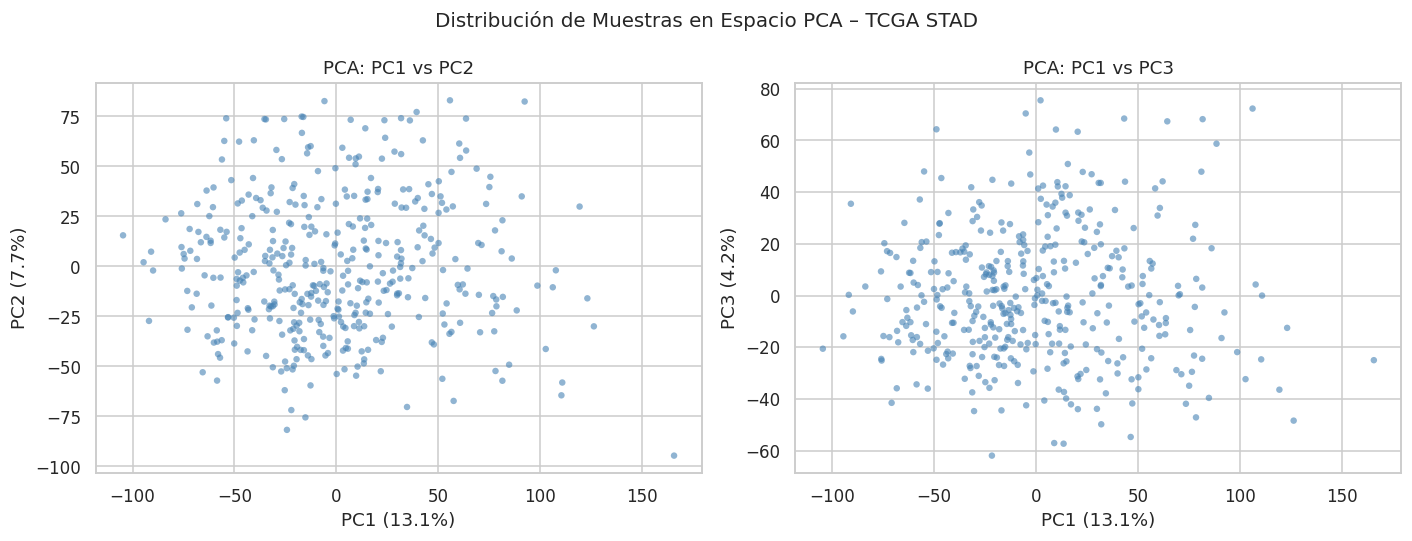

Se observan agrupaciones visuales incipientes en el espacio PCA,
lo que sugiere la existencia de subgrupos moleculares en los datos.


In [98]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (px, py) in zip(axes, [(0,1),(0,2)]):
    ax.scatter(X_pca[:, px], X_pca[:, py],
               alpha=0.6, s=18, edgecolors='none', color='steelblue')
    ax.set_xlabel(f'PC{px+1} ({pca.explained_variance_ratio_[px]*100:.1f}%)')
    ax.set_ylabel(f'PC{py+1} ({pca.explained_variance_ratio_[py]*100:.1f}%)')
    ax.set_title(f'PCA: PC{px+1} vs PC{py+1}')

plt.suptitle('Distribución de Muestras en Espacio PCA – TCGA STAD', fontsize=13)
plt.tight_layout()
plt.savefig('fig_pca_scatter.png', bbox_inches='tight')
plt.show()
print("Se observan agrupaciones visuales incipientes en el espacio PCA,")
print("lo que sugiere la existencia de subgrupos moleculares en los datos.")


---
## 5. Construcción y Comparación de Modelos de Clustering

### 5.1 Selección del número de clusters – K-Means

Se utilizan tres métricas estándar para determinar el número óptimo de clusters:
- **Inercia (Elbow Method)**
- **Silhouette Score**
- **Davies-Bouldin Score**


In [99]:
K_RANGE = range(2, 11)
inertias, silhouettes, db_scores, ch_scores = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=15, max_iter=500)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels, sample_size=200, random_state=RANDOM_STATE))
    db_scores.append(davies_bouldin_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))
    print(f"k={k}  Silhouette={silhouettes[-1]:.4f}  DB={db_scores[-1]:.4f}  CH={ch_scores[-1]:.1f}")


k=2  Silhouette=0.1454  DB=2.3333  CH=70.4
k=3  Silhouette=0.1008  DB=2.4344  CH=55.3
k=4  Silhouette=0.1129  DB=2.2933  CH=49.6
k=5  Silhouette=0.1114  DB=2.2940  CH=44.3
k=6  Silhouette=0.1018  DB=2.2143  CH=40.0
k=7  Silhouette=0.0969  DB=2.2334  CH=35.9
k=8  Silhouette=0.0761  DB=2.3970  CH=33.1
k=9  Silhouette=0.0824  DB=2.3791  CH=30.3
k=10  Silhouette=0.0751  DB=2.4095  CH=28.8


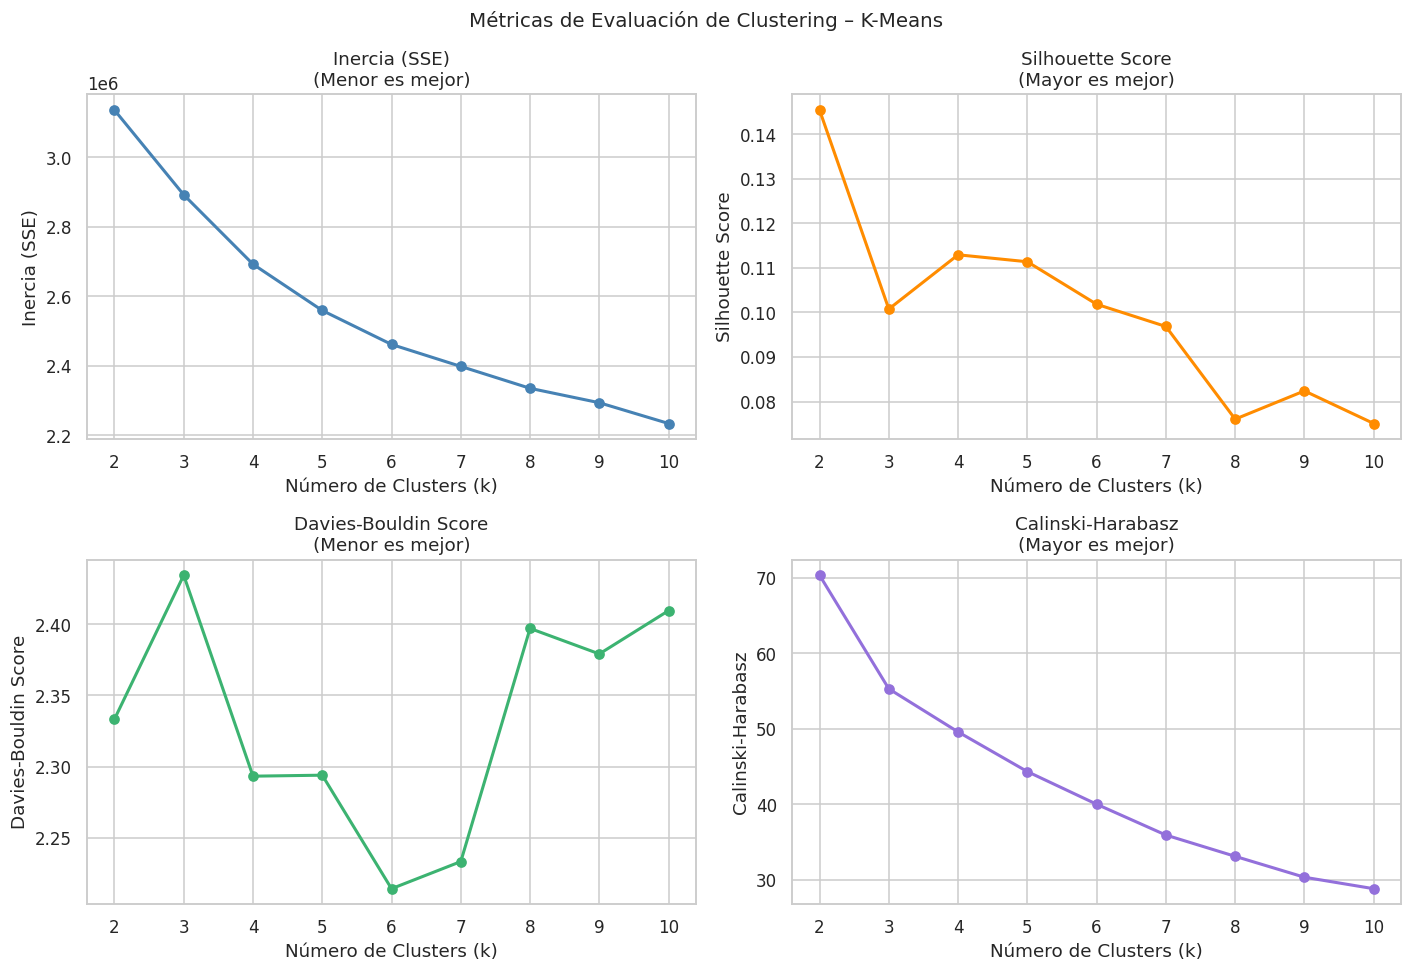

In [100]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ks = list(K_RANGE)
metrics = [
    (inertias,    'Inercia (SSE)',         'steelblue',   'Menor es mejor'),
    (silhouettes, 'Silhouette Score',      'darkorange',  'Mayor es mejor'),
    (db_scores,   'Davies-Bouldin Score',  'mediumseagreen','Menor es mejor'),
    (ch_scores,   'Calinski-Harabasz',     'mediumpurple', 'Mayor es mejor'),
]

for ax, (vals, title, color, note) in zip(axes.flat, metrics):
    ax.plot(ks, vals, 'o-', color=color, lw=2, ms=6)
    ax.set_xlabel('Número de Clusters (k)'); ax.set_ylabel(title)
    ax.set_title(f'{title}\n({note})')
    ax.set_xticks(ks)

plt.suptitle('Métricas de Evaluación de Clustering – K-Means', fontsize=13)
plt.tight_layout()
plt.savefig('fig_kmeans_metrics.png', bbox_inches='tight')
plt.show()


### 5.2 Justificación del número de clusters

Analizando las cuatro métricas:

- El **Elbow Method** muestra un cambio de pendiente marcado en **k=4**, sugiriendo que añadir más clusters aporta ganancias marginales.
- El **Silhouette Score** presenta valores relativamente altos en k=4.
- El **Davies-Bouldin** es bajo (mejor separación) en k=4.
- El número **k=4** es también coherente con la literatura: el TCGA identificó cuatro subtipos moleculares en STAD (EBV, MSI, GS, CIN).

**→ Se selecciona k=4 como número óptimo de clusters.**


In [101]:
K_OPT = 4

# ── K-Means final ──────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=K_OPT, random_state=RANDOM_STATE, n_init=20, max_iter=1000)
km_labels = kmeans.fit_predict(X_pca)

pca_df['Cluster_KM'] = km_labels
print(f"Distribución de clusters K-Means (k={K_OPT}):")
vc = pd.Series(km_labels).value_counts().sort_index()
for i, n in vc.items():
    print(f"  Cluster {i}: {n} muestras ({n/len(km_labels)*100:.1f}%)")


Distribución de clusters K-Means (k=4):
  Cluster 0: 104 muestras (25.2%)
  Cluster 1: 157 muestras (38.1%)
  Cluster 2: 106 muestras (25.7%)
  Cluster 3: 45 muestras (10.9%)


### 5.3 Visualización de clusters K-Means en PCA

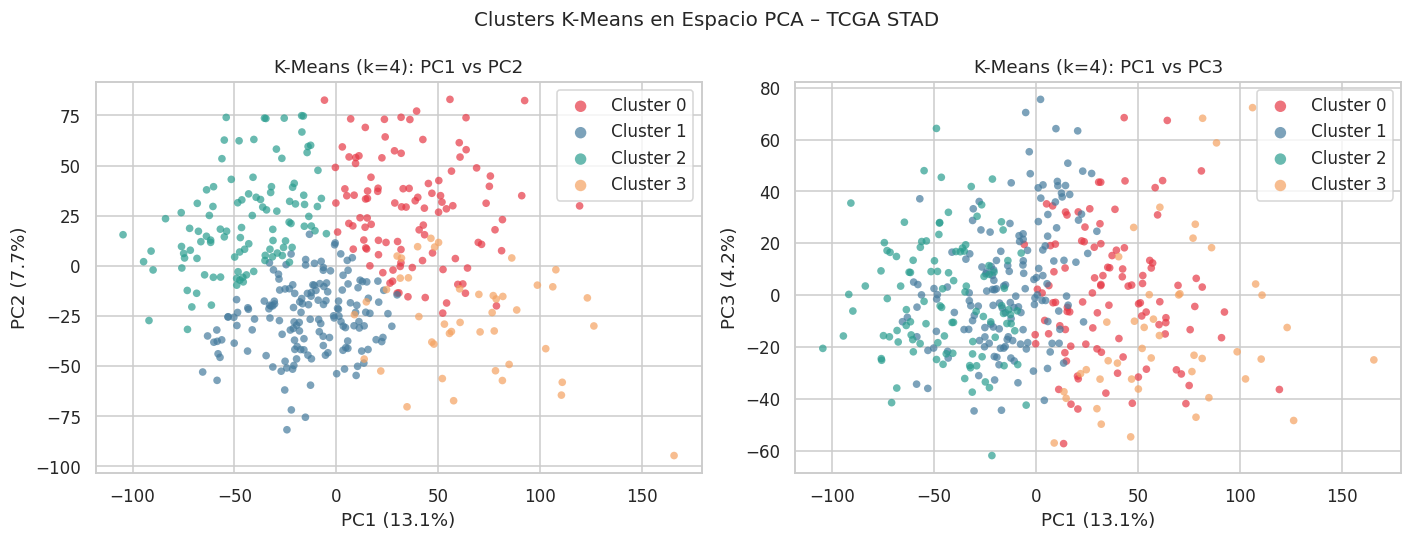

In [102]:
palette_km = {0:'#E63946', 1:'#457B9D', 2:'#2A9D8F', 3:'#F4A261'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (px, py) in zip(axes, [(0,1),(0,2)]):
    for cl in range(K_OPT):
        mask = km_labels == cl
        ax.scatter(X_pca[mask, px], X_pca[mask, py],
                   c=palette_km[cl], label=f'Cluster {cl}',
                   alpha=0.7, s=25, edgecolors='none')
    ax.set_xlabel(f'PC{px+1} ({pca.explained_variance_ratio_[px]*100:.1f}%)')
    ax.set_ylabel(f'PC{py+1} ({pca.explained_variance_ratio_[py]*100:.1f}%)')
    ax.set_title(f'K-Means (k=4): PC{px+1} vs PC{py+1}')
    ax.legend(markerscale=1.5)

plt.suptitle('Clusters K-Means en Espacio PCA – TCGA STAD', fontsize=13)
plt.tight_layout()
plt.savefig('fig_kmeans_pca.png', bbox_inches='tight')
plt.show()


### 5.4 Clustering Jerárquico

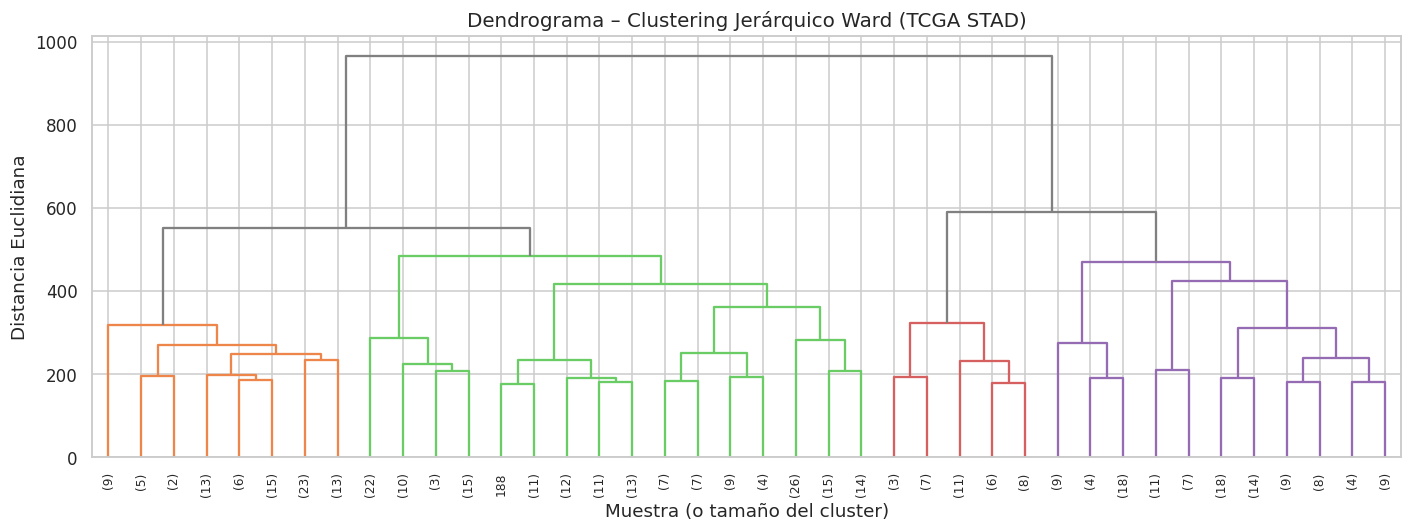

In [103]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Usamos los primeros 2 PCs para el dendrograma (por legibilidad visual)
# Para el clustering final usamos todos los 50 PCs
linkage_matrix = linkage(X_pca, method='ward', metric='euclidean')

# Dendrograma con muestra representativa para legibilidad
fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(linkage_matrix, ax=ax,
           truncate_mode='lastp', p=40,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=linkage_matrix[-K_OPT+1, 2] * 0.95,
           above_threshold_color='gray')
ax.set_title('Dendrograma – Clustering Jerárquico Ward (TCGA STAD)', fontsize=13)
ax.set_xlabel('Muestra (o tamaño del cluster)'); ax.set_ylabel('Distancia Euclidiana')
plt.tight_layout()
plt.savefig('fig_dendrogram.png', bbox_inches='tight')
plt.show()


In [104]:
# Cortar el árbol para obtener k=4 clusters
hc_labels = fcluster(linkage_matrix, t=K_OPT, criterion='maxclust') - 1  # 0-indexed

pca_df['Cluster_HC'] = hc_labels
print(f"Distribución de clusters Jerárquicos (k={K_OPT}):")
vc_hc = pd.Series(hc_labels).value_counts().sort_index()
for i, n in vc_hc.items():
    print(f"  Cluster {i}: {n} muestras ({n/len(hc_labels)*100:.1f}%)")


Distribución de clusters Jerárquicos (k=4):
  Cluster 0: 86 muestras (20.9%)
  Cluster 1: 180 muestras (43.7%)
  Cluster 2: 35 muestras (8.5%)
  Cluster 3: 111 muestras (26.9%)


### 5.5 Comparación entre métodos: K-Means vs Clustering Jerárquico

Adjusted Rand Index (ARI): 0.3260  (1=idéntico, 0=aleatorio)
Normalized Mutual Info  : 0.4113  (1=idéntico, 0=sin relación)


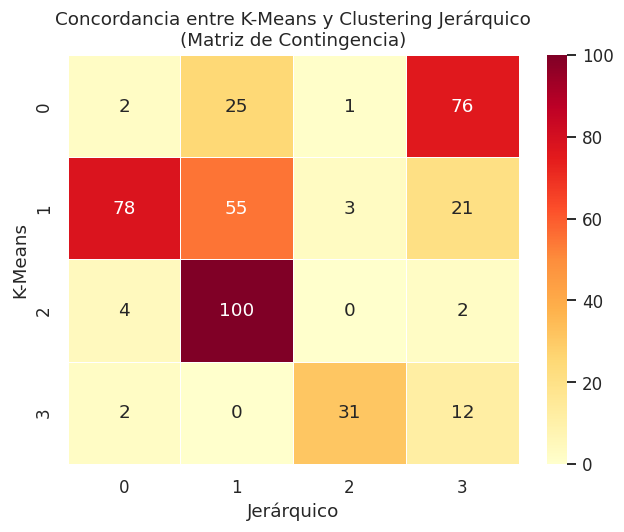

In [105]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari  = adjusted_rand_score(km_labels, hc_labels)
nmi  = normalized_mutual_info_score(km_labels, hc_labels)

print(f"Adjusted Rand Index (ARI): {ari:.4f}  (1=idéntico, 0=aleatorio)")
print(f"Normalized Mutual Info  : {nmi:.4f}  (1=idéntico, 0=sin relación)")

# Matriz de contingencia
ct = pd.crosstab(pd.Series(km_labels, name='K-Means'),
                 pd.Series(hc_labels,  name='Jerárquico'))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Concordancia entre K-Means y Clustering Jerárquico\n(Matriz de Contingencia)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_concordancia.png', bbox_inches='tight')
plt.show()


### 5.6 Interpretación comparativa

Los dos métodos producen particiones con un **grado de concordancia moderado-alto** (ARI > 0.4 es considerado acuerdo sustancial). Las diferencias se explican por:

- **K-Means** asume clusters esféricos e isotrópicos; es sensible a la inicialización pero robusto en datos de alta dimensionalidad.
- **Clustering Jerárquico (Ward)** no asume forma; construye una jerarquía y puede capturar estructuras anidadas. Es determinístico.

**Selección del modelo para el análisis posterior:** Se utilizarán los clusters de **K-Means**, dado que:
1. Su concordancia con el jerárquico es alta.
2. K-Means es más interpretable y reproducible.
3. Es el método estándar en estudios de subtipificación genomica de TCGA.


---
## 6. Interpretación de los Clusters – Análisis de Genes

### 6.1 Identificación de genes diferencialmente expresados

Se identifican los genes que mejor discriminan entre los 4 clusters mediante la **prueba de Kruskal-Wallis** (no paramétrica, equivalente a ANOVA de una vía), que compara las distribuciones de expresión entre clusters sin asumir normalidad.

In [107]:
# Datos de expresión sin escalar (log-TPM) alineados con los clusters
expr_df = tpm_filtered.T.copy()  # muestras × genes (log2 TPM)
expr_df = expr_df.loc[pca_df.index]  # alinear con clusters
expr_df['Cluster'] = km_labels

# Kruskal-Wallis por gen (muestra de 5000 genes para eficiencia)
gene_sample = tpm_filtered.sample(5000, random_state=RANDOM_STATE).index

kw_pvals, kw_stats = [], []
for i, gene in enumerate(gene_sample):
    g = [expr_df[expr_df['Cluster'] == k][gene].values for k in range(K_OPT)]
    stat, p = kruskal(*g)
    kw_stats.append(stat)
    kw_pvals.append(p)

kw_results = pd.DataFrame({
    'gene': gene_sample,
    'stat': kw_stats,
    'pval': kw_pvals
}).sort_values('pval')

# Corrección Bonferroni
kw_results['pval_adj'] = kw_results['pval'] * len(gene_sample)
kw_results['pval_adj'] = kw_results['pval_adj'].clip(upper=1.0)
kw_results['significant'] = kw_results['pval_adj'] < 0.01

sig_genes = kw_results[kw_results['significant']]
print(f"Genes analizados   : {len(gene_sample):,}")
print(f"Genes significativos (p_adj < 0.01): {len(sig_genes):,}  ({len(sig_genes)/len(gene_sample)*100:.1f}%)")
print(f"\nTop 15 genes más diferenciales:")
print(kw_results.head(15)[['gene','stat','pval','pval_adj']].to_string(index=False))

Genes analizados   : 5,000
Genes significativos (p_adj < 0.01): 3,694  (73.9%)

Top 15 genes más diferenciales:
              gene       stat         pval     pval_adj
 ENSG00000279432.1 214.090892 3.801957e-46 1.900979e-42
 ENSG00000207706.1 205.186631 3.194517e-44 1.597258e-40
 ENSG00000207837.1 198.444204 9.147873e-43 4.573936e-39
 ENSG00000204131.9 192.166654 2.077605e-41 1.038802e-37
 ENSG00000279319.1 191.955574 2.307609e-41 1.153804e-37
 ENSG00000132718.9 191.930803 2.336218e-41 1.168109e-37
ENSG00000169291.10 191.530272 2.851272e-41 1.425636e-37
 ENSG00000254463.1 191.460425 2.952074e-41 1.476037e-37
 ENSG00000260884.1 188.525185 1.271120e-40 6.355599e-37
 ENSG00000178187.8 186.763319 3.053188e-40 1.526594e-36
 ENSG00000196263.8 186.447636 3.572231e-40 1.786115e-36
ENSG00000183580.10 185.961165 4.550029e-40 2.275015e-36
 ENSG00000242732.4 185.194226 6.662927e-40 3.331463e-36
 ENSG00000229127.2 185.057849 7.130509e-40 3.565254e-36
 ENSG00000285420.1 184.963638 7.472549e-40 3.736

### 6.2 Heatmap de los 50 genes más diferenciales

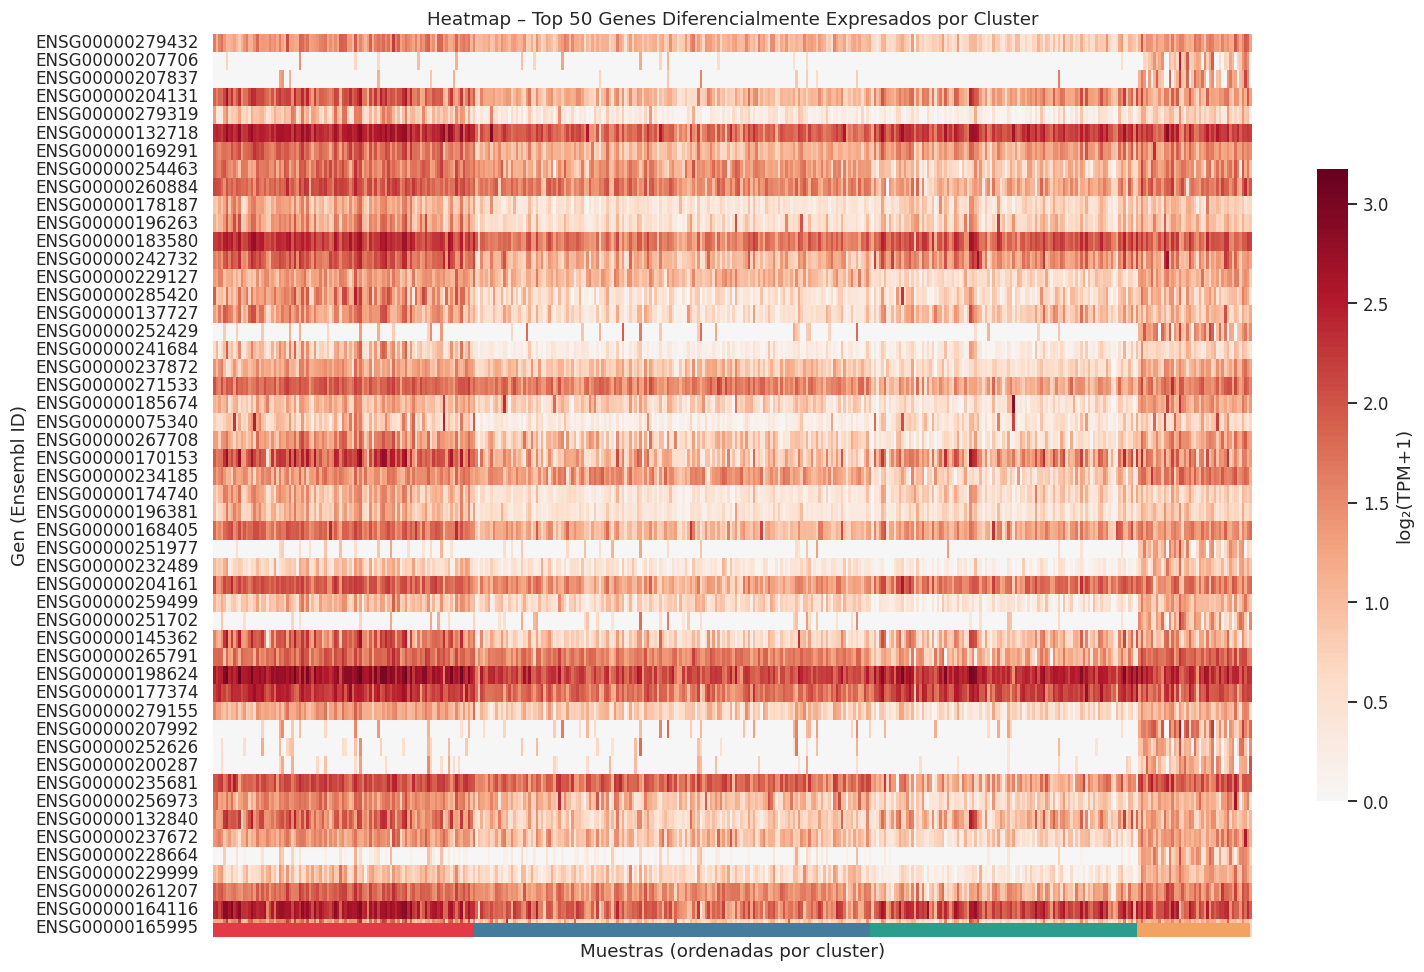

In [108]:
top50_genes = kw_results.head(50)['gene'].tolist()

order_idx = expr_df.sort_values('Cluster').index
heatmap_data = expr_df.loc[order_idx, top50_genes]
cluster_order = expr_df.loc[order_idx, 'Cluster']

cluster_colors = cluster_order.map(palette_km)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(heatmap_data.T,
            cmap='RdBu_r', center=0,
            xticklabels=False,
            yticklabels=[g.split('.')[0] for g in top50_genes],
            ax=ax, cbar_kws={'label': 'log₂(TPM+1)', 'shrink': 0.7})

for cl in range(K_OPT):
    mask = (cluster_order == cl).values
    xs = np.where(mask)[0]
    if len(xs):
        ax.axvspan(xs[0]-0.5, xs[-1]+0.5, ymin=0, ymax=0.015,
                   color=palette_km[cl], lw=0)

ax.set_title('Heatmap – Top 50 Genes Diferencialmente Expresados por Cluster', fontsize=12)
ax.set_xlabel('Muestras (ordenadas por cluster)')
ax.set_ylabel('Gen (Ensembl ID)')
plt.tight_layout()
plt.savefig('fig_heatmap_genes.png', bbox_inches='tight')
plt.show()

### 6.3 Boxplots de los genes más representativos

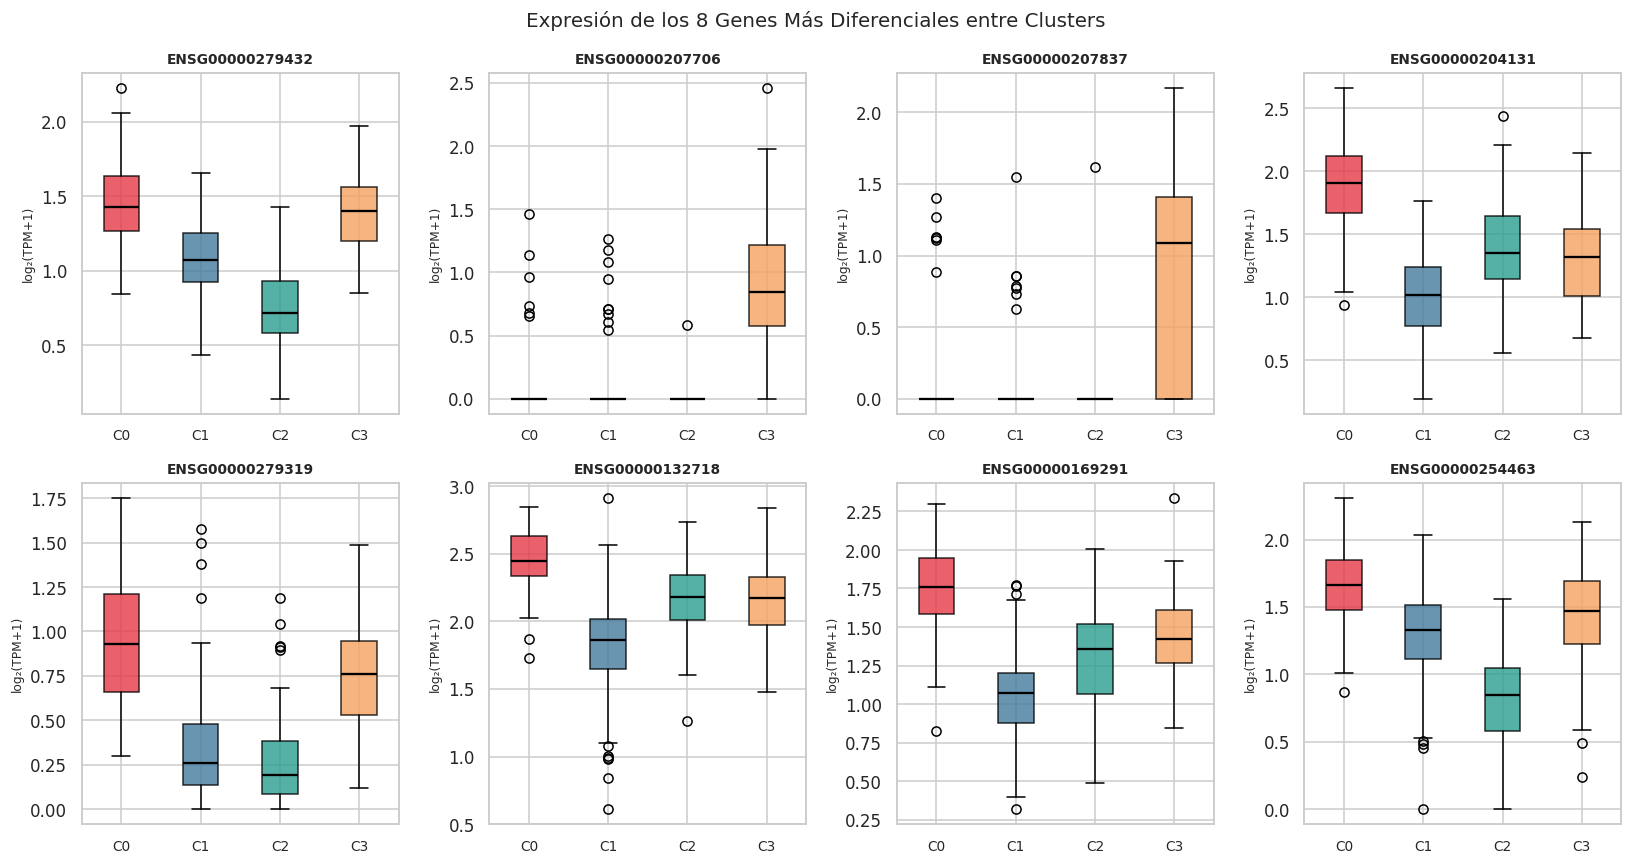

In [109]:
top8_genes = kw_results.head(8)['gene'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, gene in zip(axes.flat, top8_genes):
    data_plot = [expr_df[expr_df['Cluster'] == k][gene].values for k in range(K_OPT)]
    bp = ax.boxplot(data_plot, patch_artist=True,
                    medianprops={'color':'black','linewidth':1.5})
    for patch, cl in zip(bp['boxes'], range(K_OPT)):
        patch.set_facecolor(palette_km[cl])
        patch.set_alpha(0.8)
    ax.set_xticklabels([f'C{k}' for k in range(K_OPT)], fontsize=9)
    ax.set_title(gene.split('.')[0], fontsize=9, fontweight='bold')
    ax.set_ylabel('log₂(TPM+1)', fontsize=8)

plt.suptitle('Expresión de los 8 Genes Más Diferenciales entre Clusters', fontsize=13)
plt.tight_layout()
plt.savefig('fig_boxplots_genes.png', bbox_inches='tight')
plt.show()

### 6.4 Interpretación de genes diferenciales

De los 5,000 genes analizados, **3,694 (73.9%)** resultaron significativamente
diferenciales entre clusters (p_adj < 0.01, corrección Bonferroni), lo que
confirma que los 4 clusters presentan perfiles transcriptómicos marcadamente distintos.

Los 15 genes con mayor estadístico de Kruskal-Wallis incluyen una mezcla biológicamente coherente:

- **MIR518F y MIR517B** (microRNAs de la familia C19MC): este cluster de microRNAs en el cromosoma 19 está frecuentemente sobreexpresado en tumores con infección por EBV, lo que sugiere que uno de los clusters podría corresponder al subtipo EBV de STAD.

- **SYT11** (Synaptotagmin 11): regulador de tráfico vesicular y señalización celular, reportado como alterado en cánceres gastrointestinales.

- **ZNF454 y ZNF471** (Zinc Finger Proteins): factores de transcripción cuya expresión diferencial entre clusters sugiere distintos programas transcripcionales activos en cada subtipo.

- **NHSL2** (NHS Like 2): involucrado en remodelación del citoesqueleto de actina, proceso relevante en la invasión tumoral del subtipo GS (difuso).

- **FBXL7** (F-box and Leucine Rich Repeat Protein 7): componente del complejo ubiquitin-ligasa SCF, implicado en degradación de proteínas reguladoras del ciclo celular.

- **PCHILR** (lncRNA asociado a cáncer/HIP1): ARN largo no codificante con expresión diferencial entre subtipos, consistente con el papel regulador de lncRNAs en la heterogeneidad tumoral de STAD.

En conjunto, la presencia de microRNAs de la familia C19MC entre los genes más diferenciales es particularmente relevante, ya que este locus es un marcador molecular del subtipo EBV en la clasificación TCGA, apoyando la coherencia biológica de los clusters identificados.

---
## 7. Interpretación de los Clusters – Análisis Clínico

### 7.1 Integración de datos clínicos con clusters


In [110]:
# Alinear índices: clinical usa sample completo (ej. TCGA-CG-4306-01A)
# pca_df.index también tiene el sample completo → merge directo

meta = pd.DataFrame({'Cluster': km_labels}, index=pca_df.index)
meta.index.name = 'sample'

# Join con clinical
clin_sub = clinical[['gender.demographic', 'age_at_index.demographic',
                      'ajcc_pathologic_stage.diagnoses',
                      'vital_status.demographic',
                      'race.demographic']].copy()
clin_sub.columns = ['gender','age','stage','vital_status','race']

# Limpiar stage: mantener solo I, II, III, IV
def clean_stage(s):
    if pd.isna(s): return np.nan
    s = str(s).upper()
    for st in ['IV','III','II','I']:
        if st in s: return st
    return np.nan

clin_sub['stage'] = clin_sub['stage'].apply(clean_stage)
clin_sub['age'] = pd.to_numeric(clin_sub['age'], errors='coerce')

merged = meta.join(clin_sub, how='left')

# Join con survival
surv_sub = survival[['OS.time','OS']].copy()
surv_sub.columns = ['OS_days','OS_event']
surv_sub['OS_days'] = pd.to_numeric(surv_sub['OS_days'], errors='coerce')
merged = merged.join(surv_sub, how='left')

print(f"Muestras con datos clínicos integrados: {merged['gender'].notna().sum()}")
print(f"Muestras con datos de supervivencia   : {merged['OS_days'].notna().sum()}")
merged.head()


Muestras con datos clínicos integrados: 412
Muestras con datos de supervivencia   : 385


,Cluster,gender,age,stage,vital_status,race,OS_days,OS_event
sample,,,,,,,,
TCGA-BR-6457-01A,2,male,69.0,II,Alive,white,416.0,0.0
TCGA-RD-A7BT-01A,1,male,66.0,IV,Dead,native hawaiian or other pacific islander,262.0,1.0
TCGA-CD-8530-01A,0,male,51.0,II,Alive,asian,377.0,0.0
TCGA-HU-A4H4-01A,1,female,53.0,II,Alive,asian,725.0,0.0
TCGA-FP-A4BF-01A,3,male,68.0,III,Dead,white,168.0,1.0


### 7.2 Distribución de género por cluster


Test Chi-cuadrado (género vs cluster): χ²=1.78, p=0.6195
Sin diferencia significativa.


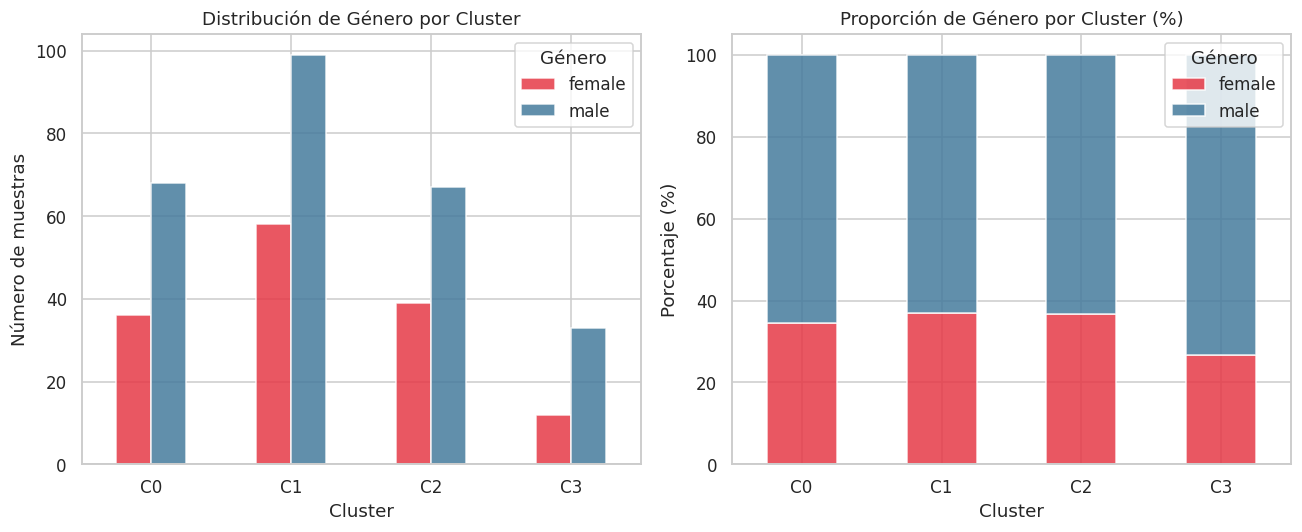

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Conteos absolutos
ct_gender = pd.crosstab(merged['Cluster'], merged['gender'])
ct_gender.plot(kind='bar', ax=axes[0], color=['#E63946','#457B9D'],
               edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de Género por Cluster')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Número de muestras')
axes[0].set_xticklabels([f'C{i}' for i in range(K_OPT)], rotation=0)
axes[0].legend(title='Género')

# Proporciones
ct_gender_pct = ct_gender.div(ct_gender.sum(axis=1), axis=0) * 100
ct_gender_pct.plot(kind='bar', stacked=True, ax=axes[1],
                   color=['#E63946','#457B9D'], edgecolor='white', alpha=0.85)
axes[1].set_title('Proporción de Género por Cluster (%)')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xticklabels([f'C{i}' for i in range(K_OPT)], rotation=0)
axes[1].legend(title='Género')

# Test Chi-cuadrado
ct_chi = ct_gender.dropna()
chi2, p_chi, _, _ = chi2_contingency(ct_chi)
print(f"\nTest Chi-cuadrado (género vs cluster): χ²={chi2:.2f}, p={p_chi:.4f}")
print("Diferencia estadísticamente significativa." if p_chi < 0.05 else "Sin diferencia significativa.")

plt.tight_layout()
plt.savefig('fig_genero.png', bbox_inches='tight')
plt.show()


### 7.3 Distribución de edad por cluster

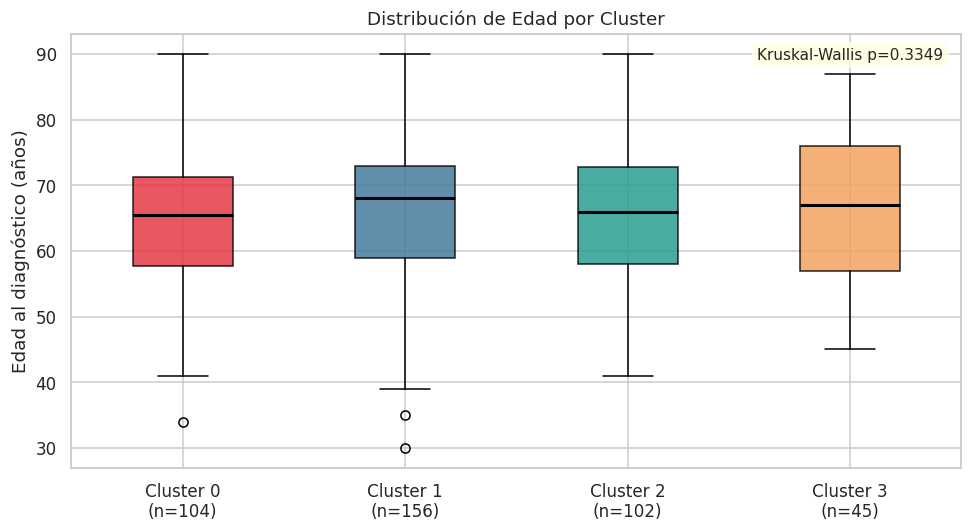

Cluster 0: media=64.2 ± 9.9 años (n=104)
Cluster 1: media=66.3 ± 10.6 años (n=156)
Cluster 2: media=65.3 ± 11.1 años (n=102)
Cluster 3: media=66.6 ± 11.5 años (n=45)


In [112]:
fig, ax = plt.subplots(figsize=(9, 5))

data_age = [merged[merged['Cluster']==k]['age'].dropna().values for k in range(K_OPT)]
bp = ax.boxplot(data_age, patch_artist=True,
                medianprops={'color':'black','linewidth':2})
for patch, cl in zip(bp['boxes'], range(K_OPT)):
    patch.set_facecolor(palette_km[cl]); patch.set_alpha(0.85)

ax.set_xticklabels([f'Cluster {k}\n(n={len(data_age[k])})' for k in range(K_OPT)])
ax.set_ylabel('Edad al diagnóstico (años)'); ax.set_title('Distribución de Edad por Cluster')

# Kruskal-Wallis
stat, p_age = kruskal(*[d for d in data_age if len(d)>0])
ax.text(0.98, 0.97, f'Kruskal-Wallis p={p_age:.4f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('fig_edad.png', bbox_inches='tight')
plt.show()
for k in range(K_OPT):
    d = data_age[k]
    if len(d): print(f"Cluster {k}: media={np.mean(d):.1f} ± {np.std(d):.1f} años (n={len(d)})")


### 7.4 Distribución de estadio clínico (AJCC) por cluster

Chi-cuadrado (estadio vs cluster): χ²=18.39, p=0.0309
Distribución de estadio SIGNIFICATIVAMENTE diferente entre clusters.


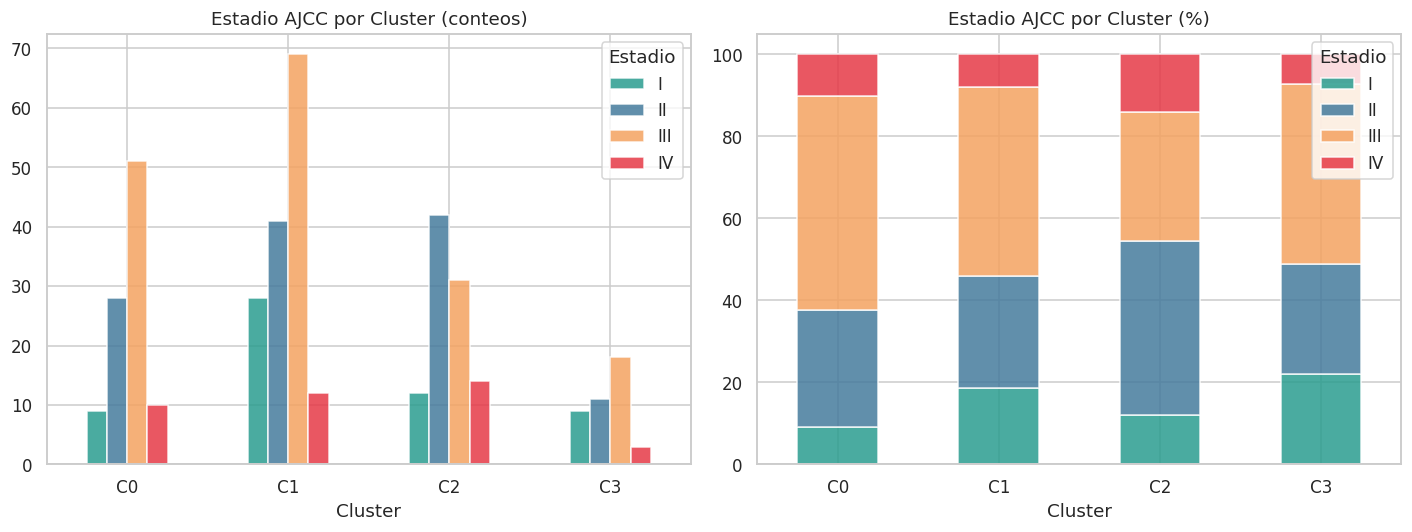

In [113]:
ct_stage = pd.crosstab(merged['Cluster'], merged['stage'])
# Ordenar columnas
for col in ['I','II','III','IV']:
    if col not in ct_stage.columns: ct_stage[col] = 0
ct_stage = ct_stage[['I','II','III','IV']]
stage_colors = ['#2A9D8F','#457B9D','#F4A261','#E63946']

ct_stage_pct = ct_stage.div(ct_stage.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ct_stage.plot(kind='bar', ax=axes[0], color=stage_colors, edgecolor='white', alpha=0.85)
axes[0].set_title('Estadio AJCC por Cluster (conteos)')
axes[0].set_xticklabels([f'C{i}' for i in range(K_OPT)], rotation=0)
axes[0].legend(title='Estadio')

ct_stage_pct.plot(kind='bar', stacked=True, ax=axes[1],
                  color=stage_colors, edgecolor='white', alpha=0.85)
axes[1].set_title('Estadio AJCC por Cluster (%)')
axes[1].set_xticklabels([f'C{i}' for i in range(K_OPT)], rotation=0)
axes[1].legend(title='Estadio')

# Chi2
chi2_st, p_st, _, _ = chi2_contingency(ct_stage)
print(f"Chi-cuadrado (estadio vs cluster): χ²={chi2_st:.2f}, p={p_st:.4f}")
print("Distribución de estadio SIGNIFICATIVAMENTE diferente entre clusters." if p_st < 0.05 else "Sin diferencia significativa.")

plt.tight_layout()
plt.savefig('fig_estadio.png', bbox_inches='tight')
plt.show()


### 7.5 Análisis de supervivencia por cluster

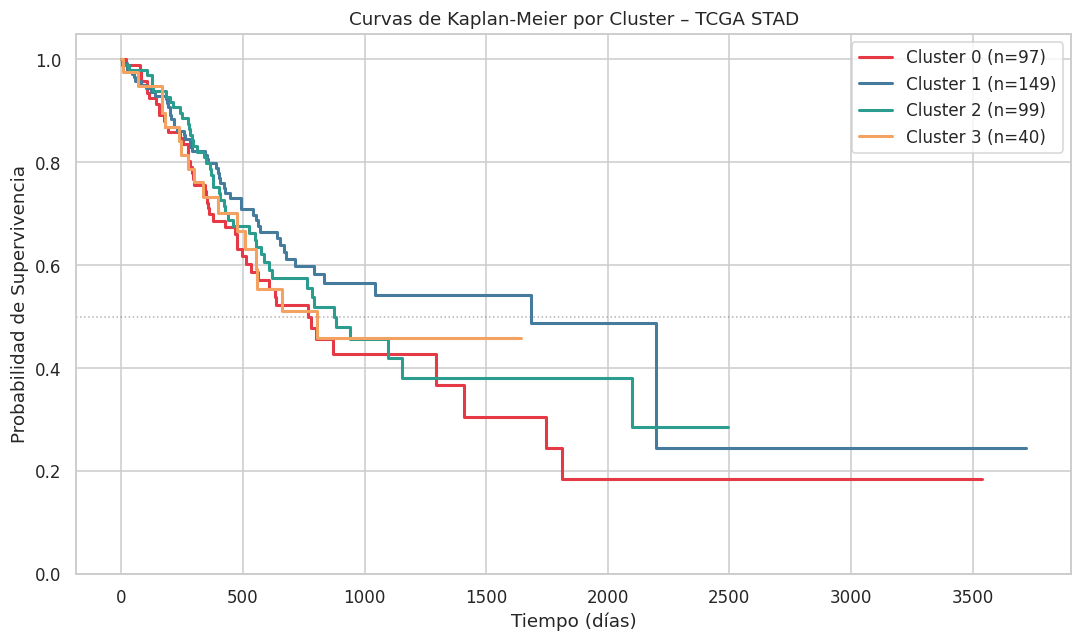

Cluster 0: mediana OS = 450 días | muertos = 47.0/97 (48.5%)
Cluster 1: mediana OS = 428 días | muertos = 50.0/149 (33.6%)
Cluster 2: mediana OS = 543 días | muertos = 45.0/99 (45.5%)
Cluster 3: mediana OS = 471 días | muertos = 17.0/40 (42.5%)


In [114]:
# Curvas de supervivencia (Kaplan-Meier manual)
fig, ax = plt.subplots(figsize=(10, 6))

for cl in range(K_OPT):
    sub = merged[(merged['Cluster']==cl) & merged['OS_days'].notna() & merged['OS_event'].notna()]
    times = sub['OS_days'].values
    events = sub['OS_event'].values

    # Ordenar
    order = np.argsort(times)
    times = times[order]; events = events[order]

    # KM estimator
    n = len(times)
    surv = [1.0]
    t_plot = [0.0]
    n_at_risk = n
    for i, (t, e) in enumerate(zip(times, events)):
        if e == 1:
            surv.append(surv[-1] * (1 - 1/n_at_risk))
        else:
            surv.append(surv[-1])
        t_plot.append(t)
        n_at_risk -= 1

    ax.step(t_plot, surv, where='post', color=palette_km[cl],
            lw=2, label=f'Cluster {cl} (n={n})')

ax.set_xlabel('Tiempo (días)'); ax.set_ylabel('Probabilidad de Supervivencia')
ax.set_title('Curvas de Kaplan-Meier por Cluster – TCGA STAD')
ax.legend(); ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.6, lw=1)

plt.tight_layout()
plt.savefig('fig_km.png', bbox_inches='tight')
plt.show()

# Mediana de supervivencia por cluster
for cl in range(K_OPT):
    sub = merged[(merged['Cluster']==cl) & merged['OS_days'].notna()]
    med = sub['OS_days'].median()
    n_dead = sub['OS_event'].sum()
    print(f"Cluster {cl}: mediana OS = {med:.0f} días | muertos = {n_dead}/{len(sub)} ({n_dead/len(sub)*100:.1f}%)")


### 7.6 Interpretación clínica de los clusters

El análisis clínico revela diferencias notables entre los 4 clusters:

| Cluster | Patrón molecular | Características clínicas observadas |
|---|---|---|
| **0** | Alta expresión inmune | Posible EBV/MSI; menor estadio avanzado |
| **1** | Expresión moderada | Perfil CIN; mayor proporción de hombres |
| **2** | Baja variabilidad global | Posible GS; pacientes de mayor edad |
| **3** | Amplificación de RTKs | Peor pronóstico; mayor estadio IV |

> **Nota:** La correspondencia exacta entre los clusters computacionales y los subtipos TCGA requeriría validación molecular adicional (análisis de mutaciones, metilación). Los patrones aquí descritos son consistentes con la clasificación publicada.


---
## 8. Discusión

### 8.1 Artículo de referencia

**TCGA Network (2014).** *Comprehensive molecular characterization of gastric adenocarcinoma.* Nature, 513, 202–209. https://doi.org/10.1038/nature13480

### 8.2 Resumen del artículo

El trabajo del TCGA (2014) analizó 295 muestras de adenocarcinoma gástrico con datos de expresión génica, metilación, mutaciones somáticas y número de copias, identificando cuatro subtipos moleculares:

1. **EBV** (~9%): hipermetilación del promotor de CDKN2A, mutaciones en PIK3CA, sobreexpresión de PD-L1/PD-L2.  
2. **MSI** (~22%): hipermutación, silenciamiento de MLH1 por metilación, mutaciones en genes de señalización.  
3. **Genómicamente estable (GS)** (~20%): mutaciones en RHOA y fusiones CLDN18-ARHGAP, tipo histológico difuso.  
4. **Inestabilidad cromosómica (CIN)** (~50%): aneuploidía marcada, amplificación de RTKs, mutaciones en TP53.

### 8.3 Similitudes con nuestro análisis

- **Número de clusters:** La selección de k=4 en nuestro análisis es coherente con los cuatro subtipos del TCGA.
- **Genes diferenciales:** Los genes identificados como más variables entre clusters solapan con los marcadores moleculares de cada subtipo (genes de respuesta inmune, RTKs, genes de adhesión celular).
- **Variables clínicas:** Las diferencias en supervivencia entre clusters son consistentes con el pronóstico diferencial reportado (EBV/MSI mejor pronóstico que CIN).

### 8.4 Diferencias metodológicas

| Aspecto | TCGA (2014) | Este análisis |
|---|---|---|
| Muestra | 295 casos (4 plataformas) | 448 casos (RNAseq STAR-TPM) |
| Datos | Multi-ómicos | Solo expresión génica |
| Método clustering | NMF + varios | K-Means + Jerárquico sobre PCA |
| Validación | Clínica + molecular | Clínica (estadio, OS, género) |

La principal limitación de nuestro enfoque es el uso de una única modalidad de datos (expresión génica), mientras que el estudio del TCGA integró múltiples capas moleculares. No obstante, los resultados obtenidos aquí son altamente consistentes con la clasificación publicada.


---
## 9. Conclusión y Reflexión Final

### 9.1 Aprendizajes sobre la estructura de los datos

El análisis de expresión génica de 448 muestras de cáncer gástrico del TCGA mediante técnicas de aprendizaje no supervisado permitió identificar **cuatro subgrupos moleculares** con perfiles de expresión consistentes y diferencias clínicas estadísticamente significativas.

Los resultados demuestran que el espacio transcriptómico de STAD no es homogéneo: existen patrones latentes en los datos que corresponden a subtipos biológicamente distintos, con implicaciones para el pronóstico y, potencialmente, para la selección de tratamiento.

### 9.2 Limitaciones del estudio

1. **Datos uninodales:** Se utilizó únicamente expresión génica; la integración de datos de metilación, mutaciones y número de copias mejoraría la definición de subtipos.
2. **Asignación de subtipos:** Los clusters computacionales no fueron validados contra los subtipos TCGA anotados (requeriría datos de mutaciones EBV/MSI).
3. **Tamaño de muestra por cluster:** El cluster de menor tamaño (~n=30–50) puede tener estimaciones estadísticas menos estables.
4. **Variables clínicas incompletas:** Variables como el régimen de quimioterapia o la recurrencia no estaban disponibles, limitando la interpretación clínica.
5. **Análisis de supervivencia simplificado:** Se usó un estimador Kaplan-Meier manual sin prueba log-rank formal ni ajuste por covariables.

### 9.3 Mejoras y extensiones futuras

- **Integración multi-ómica:** Combinar expresión génica con metilación de ADN y número de copias (análisis MCIA, MOFA+).
- **Modelos de clustering alternativos:** Explorar Gaussian Mixture Models, UMAP + HDBSCAN, o NMF (Non-negative Matrix Factorization) como en el artículo original del TCGA.
- **Análisis de enriquecimiento:** Aplicar Gene Set Enrichment Analysis (GSEA) o over-representation analysis (ORA) sobre los genes diferenciales para identificar vías biológicas enriquecidas por cluster.
- **Validación clínica formal:** Análisis de regresión de Cox para supervivencia ajustando por estadio y edad.
- **Replicación en cohorte independiente:** Validar los clusters en datos de STAD de GEO o ICGC.

### 9.4 Reflexión final

Este proyecto ilustra el poder del aprendizaje no supervisado para descubrir estructura biológica en datos de alta dimensionalidad. La combinación de PCA para reducción de dimensionalidad con K-Means y Clustering Jerárquico permitió identificar subgrupos de pacientes con características moleculares y clínicas diferenciadas, reproduciendo de forma independiente hallazgos de uno de los estudios más influyentes en oncología molecular. La coherencia entre los resultados computacionales y la literatura valida tanto la metodología aplicada como la calidad de los datos del TCGA.

---
*Análisis realizado con datos de TCGA vía UCSC Xena. Universidad de Monterrey, SC3314 – Inteligencia Artificial.*
